In [1]:
!pip install nltk


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# 2. Standard Library Imports
import re

# 3. Third-Party Library Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

# 4. NLTK Specific Imports
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# 5. Scikit-Learn Imports (Preprocessing & Metrics)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer
from sklearn.metrics import classification_report, hamming_loss

# 6. TensorFlow/Keras Imports (Deep Learning)
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, Dense, Dropout,
                                     Bidirectional, GRU, SimpleRNN)
from tensorflow.keras.callbacks import EarlyStopping

# 7. NLTK Downloads
def initialize_nlp():
    """Initializes necessary NLTK resources."""
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)
    nltk.download('punkt', quiet=True)
    nltk.download('omw-1.4', quiet=True) # Recommended for Lemmatizer

if __name__ == "__main__":
    initialize_nlp()

In [3]:
import pandas as pd

#load the training data
train_df=pd.read_csv(r'C:\Users\Sumathi\OneDrive\Documents\Toxicity_project\train.csv')
print("Train Data Shape:", train_df.shape)

Train Data Shape: (159571, 8)


In [4]:
train_df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [5]:
train_df.tail()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0
159570,fff46fc426af1f9a,"""\nAnd ... I really don't think you understand...",0,0,0,0,0,0


In [6]:
train_df.columns

Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')

In [7]:
train_df.isnull().sum()

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

In [ ]:
                                #Text Cleaning


In [8]:
import re
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"\'s", " ", text)
    text = re.sub(r"\'ve", " have ", text)
    text = re.sub(r"can't", "can not ", text)
    text = re.sub(r"n't", " not ", text)
    text = re.sub(r"i'm", "i am ", text)
    text = re.sub(r"\'re", " are ", text)
    text = re.sub(r"\'d", " would ", text)
    text = re.sub(r"\'ll", " will ", text)
    text = re.sub(r"[^a-zA-Z!?\s]", " ", text)


    #Lemmatization
    # This turns "hating" -> "hate", "rocks" -> "rock", etc.
    text = " ".join([lemmatizer.lemmatize(word) for word in text.split()])

    # Spacing
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text

# Apply it
train_df['cleaned_comment'] = train_df['comment_text'].apply(clean_text)
train_df['cleaned_comment']

0         explanation why the edits made under my userna...
1         d aww! he match this background colour i am se...
2         hey man i am really not trying to edit war it ...
3         more i can not make any real suggestion on imp...
4         you sir are my hero any chance you remember wh...
                                ...                        
159566    and for the second time of asking when your vi...
159567    you should be ashamed of yourself that is a ho...
159568    spitzer umm there no actual article for prosti...
159569    and it look like it wa actually you who put on...
159570    and i really do not think you understand i cam...
Name: cleaned_comment, Length: 159571, dtype: object

In [ ]:
                                    # Splitting the Data


In [9]:
from sklearn.model_selection import train_test_split

X = train_df['comment_text']
y = train_df[['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']].values

X_Train,X_Test,y_Train,y_Test=train_test_split(X,y,test_size=0.2)
X_Train.shape,X_Test.shape,y_Train.shape,y_Test.shape

((127656,), (31915,), (127656, 6), (31915, 6))

In [ ]:
                                    # Vectorization & Padding

In [10]:
# 1. Initialize the Tokenizer
MAX_WORDS = 20000
MAX_LEN = 150
tokenizer = Tokenizer(num_words=MAX_WORDS)

# 2. ONLY fit on the training data (X_Train)
tokenizer.fit_on_texts(X_Train)

# 3. Convert BOTH to sequences
X_Train_seq = tokenizer.texts_to_sequences(X_Train)
X_Test_seq = tokenizer.texts_to_sequences(X_Test)

# 4. Pad BOTH to the same length
X_Train_padded = pad_sequences(X_Train_seq, maxlen=MAX_LEN)
X_Test_padded = pad_sequences(X_Test_seq, maxlen=MAX_LEN)

print("X_Train shape:", X_Train_padded.shape)
print("X_Test shape:", X_Test_padded.shape)

X_Train shape: (127656, 150)
X_Test shape: (31915, 150)


Breakdown per category:
toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64


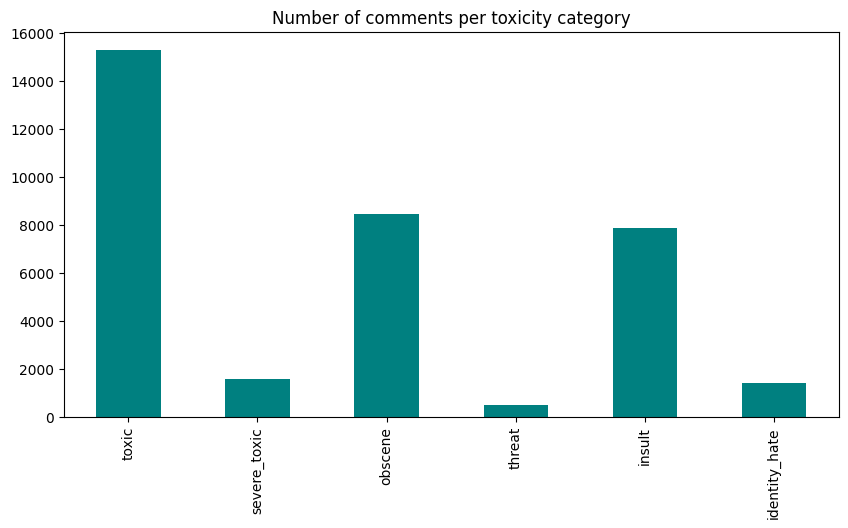

In [11]:
# Create a labels list for easy reading
categories = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Calculate counts for each column
label_counts = train_df[categories].sum()

print("Breakdown per category:")
print(label_counts)

# Visualize it
import matplotlib.pyplot as plt
label_counts.plot(kind='bar', figsize=(10, 5), color='teal')
plt.title('Number of comments per toxicity category')
plt.show()

In [12]:
                            #Create a TensorFlow Data Pipeline

In [13]:
import tensorflow as tf

# Convert vectorized data and labels into a TF Dataset

train_dataset = tf.data.Dataset.from_tensor_slices((X_Train_padded, y_Train))
train_dataset = train_dataset.cache().shuffle(160000).batch(16).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_Test_padded, y_Test))
val_dataset = val_dataset.batch(16).prefetch(tf.data.AUTOTUNE)

print("TF Datasets created successfully!")


TF Datasets created successfully!


In [13]:
                               # Calculate Weights

In [14]:
import numpy as np

# Count total samples and count of 'clean' comments
total_samples = len(y_Train)
# A comment is clean if the sum of its labels is 0
clean_count = np.sum(np.all(y_Train == 0, axis=1))
toxic_count = total_samples - clean_count

# Calculate weights: Higher weight for the smaller group (toxic)
weight_for_0 = (1 / clean_count) * (total_samples / 2.0)
weight_for_1 = (1 / toxic_count) * (total_samples / 2.0)

class_weights = {0: weight_for_0, 1: weight_for_1}

print(f"Weight for Clean (0): {weight_for_0:.2f}")
print(f"Weight for Toxic (1): {weight_for_1:.2f}")

Weight for Clean (0): 0.56
Weight for Toxic (1): 4.91


In [ ]:
                       # Build the Deep Learning Model (LSTM)

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout

from tensorflow.keras.layers import Input

model = Sequential([
    # Add an Input layer here to "build" the model immediately
    Input(shape=(MAX_LEN,)), 
    
    Embedding(MAX_WORDS + 1, 32), # Removed input_length as it's in Input() now
    Bidirectional(LSTM(32)),
    Dense(128, activation='relu'),
    Dense(256, activation='relu'),
    Dense(6, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary() # Now this will show millions of parameters!

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 32)        │       640,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 699,558 (2.67 MB)

 Trainable params: 699,558 (2.67 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
                          #Training the Model

In [17]:
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
# 1. Identify which rows are "Toxic" (any label is 1) vs "Clean" (all labels 0)
is_toxic = np.any(y_Train == 1, axis=1)

# 2. Create an array of weights for every single row in your training set
# We initialize with the weight for 'Clean'
sample_weights = np.where(is_toxic, weight_for_1, weight_for_0)

# 3. Update your TF Dataset to include these weights
# TF Datasets expect a (features, labels, weights) tuple
train_dataset = tf.data.Dataset.from_tensor_slices((X_Train_padded, y_Train, sample_weights))
train_dataset = train_dataset.cache().shuffle(160000).batch(64).prefetch(tf.data.AUTOTUNE)

# This will stop training if the model stops improving, saving you time
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(
    train_dataset,        # Use the dataset object, NOT X_Train_padded
    validation_data=val_dataset, # Use the dataset object, NOT X_Test_padded
    epochs=10,
    callbacks=[early_stop],
    verbose=1
)

                          #Evaluate the Model  

Epoch 1/10
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 580s 288ms/step - accuracy: 0.9800 - loss: 0.1775 - val_accuracy: 0.9945 - val_loss: 0.0622
Epoch 2/10
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 586s 293ms/step - accuracy: 0.9538 - loss: 0.1630 - val_accuracy: 0.9482 - val_loss: 0.0543
Epoch 3/10
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 594s 298ms/step - accuracy: 0.8699 - loss: 0.1460 - val_accuracy: 0.9935 - val_loss: 0.0588
Epoch 4/10
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 634s 304ms/step - accuracy: 0.9060 - loss: 0.1296 - val_accuracy: 0.8068 - val_loss: 0.0572


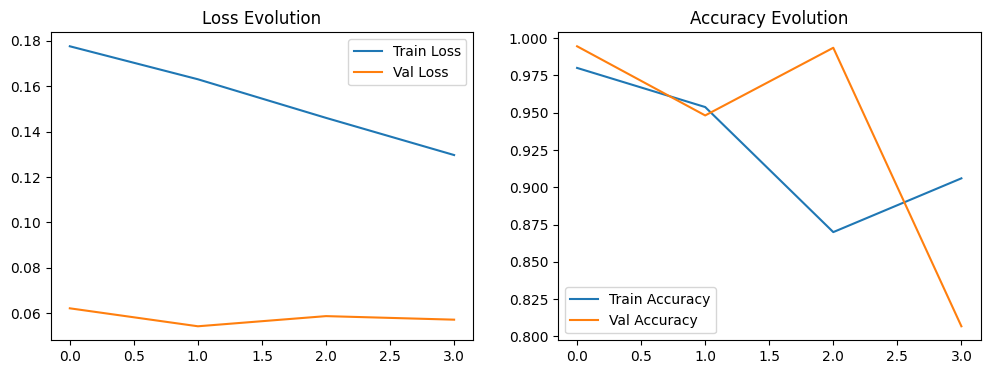

In [18]:
import matplotlib.pyplot as plt

# 1. Plot Training & Validation Loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Evolution')
plt.legend()

# 2. Plot Training & Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Evolution')
plt.legend()
plt.show()



In [19]:
import pickle

# 1. Save the Model (The Brain)
model.save(r'C:\Users\Sumathi\OneDrive\Documents\Toxicity_project\toxicity_model.h5')
print("Model saved successfully!")



Model saved successfully!


In [20]:
# 2. Save the Tokenizer (The Dictionary)
# This is a MUST for your Streamlit app
with open('tokenizer.pkl', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
print("✅ Tokenizer saved: tokenizer.pkl")
print("Model and Tokenizer loaded instantly!")

✅ Tokenizer saved: tokenizer.pkl
Model and Tokenizer loaded instantly!


In [ ]:
import tensorflow as tf
import pickle

# 1. Load the Model (.h5 file)
# Uses the Keras built-in loader
model = tf.keras.models.load_model('toxicity_model.h5')
print("✅ Model loaded successfully!")

# 2. Load the Tokenizer (.pkl or .pickle file)
# Uses the pickle library in 'rb' (read binary) mode
with open('tokenizer.pkl', 'rb') as handle:
    tokenizer = pickle.load(handle)
print("✅ Tokenizer loaded successfully!")

✅ Model loaded successfully!
✅ Tokenizer loaded successfully!


In [ ]:
#Load the Test.csv file

In [20]:
test_df = pd.read_csv(r'C:\Users\Sumathi\OneDrive\Documents\Toxicity_project\test.csv')

In [21]:
test_df.head()

,id,comment_text
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...
1,0000247867823ef7,== From RfC == \n\n The title is fine as it is...
2,00013b17ad220c46,""" \n\n == Sources == \n\n * Zawe Ashton on Lap..."
3,00017563c3f7919a,":If you have a look back at the source, the in..."
4,00017695ad8997eb,I don't anonymously edit articles at all.


In [22]:
test_df.tail()

,id,comment_text
153159,fffcd0960ee309b5,". \n i totally agree, this stuff is nothing bu..."
153160,fffd7a9a6eb32c16,== Throw from out field to home plate. == \n\n...
153161,fffda9e8d6fafa9e,""" \n\n == Okinotorishima categories == \n\n I ..."
153162,fffe8f1340a79fc2,""" \n\n == """"One of the founding nations of the..."
153163,ffffce3fb183ee80,""" \n :::Stop already. Your bullshit is not wel..."


In [ ]:
# --- PART 1: SETUP & LOAD ---
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle
import re
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"\'s", " ", text)
    text = re.sub(r"\'ve", " have ", text)
    text = re.sub(r"can't", "can not ", text)
    text = re.sub(r"n't", " not ", text)
    text = re.sub(r"i'm", "i am ", text)
    text = re.sub(r"\'re", " are ", text)
    text = re.sub(r"\'d", " would ", text)
    text = re.sub(r"\'ll", " will ", text)
    text = re.sub(r"[^a-zA-Z!?\s]", " ", text)

    text = " ".join([lemmatizer.lemmatize(word) for word in text.split()])
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text 
# 1. Load the test data
model = tf.keras.models.load_model(r'C:\Users\Sumathi\OneDrive\Documents\Toxicity_project\toxicity_model.h5')
with open(r'C:\Users\Sumathi\OneDrive\Documents\Toxicity_project\tokenizer.pkl', 'rb') as handle:
    tokenizer = pickle.load(handle)

MAX_LEN = 150

import pandas as pd
test_df = pd.read_csv(r'C:\Users\Sumathi\OneDrive\Documents\Toxicity_project\test.csv')

# 2. Clean the text (using the same modular function)
print("Cleaning test data...")
test_df['comment_text'] = test_df['comment_text'].apply(clean_text)

# 3. Vectorize and Pad
# Use the same tokenizer and MAX_LEN used for training
test_sequences = tokenizer.texts_to_sequences(test_df['comment_text'])
test_padded = pad_sequences(test_sequences, maxlen=MAX_LEN)

# 4. Generate Predictions
print("Predicting toxicity...")
predictions = model.predict(test_padded)

# 5. Create a clean results table
categories = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
prediction_df = pd.DataFrame(predictions, columns=categories)

# Combine with the original ID (if applicable) and save
final_results = pd.concat([test_df['id'], prediction_df], axis=1)
final_results.to_csv('test_predictions.csv', index=False)

print("Final predictions saved as test_predictions.csv!")

Cleaning test data...
Predicting toxicity...
4787/4787 ━━━━━━━━━━━━━━━━━━━━ 438s 86ms/step
Final predictions saved as test_predictions.csv!


In [24]:
print(final_results.head(10))

                 id     toxic  severe_toxic   obscene    threat    insult  \
0  00001cee341fdb12  0.500120      0.499938  0.499364  0.501086  0.499527   
1  0000247867823ef7  0.499566      0.500170  0.498515  0.500403  0.498853   
2  00013b17ad220c46  0.499234      0.500541  0.496714  0.500922  0.498725   
3  00017563c3f7919a  0.499008      0.499535  0.499226  0.500583  0.499040   
4  00017695ad8997eb  0.499499      0.499791  0.498031  0.500585  0.498969   
5  0001ea8717f6de06  0.499962      0.499767  0.499906  0.501128  0.499448   
6  00024115d4cbde0f  0.499365      0.500023  0.499077  0.500630  0.498812   
7  000247e83dcc1211  0.499940      0.500780  0.497773  0.501181  0.499331   
8  00025358d4737918  0.499558      0.500852  0.498586  0.500594  0.499056   
9  00026d1092fe71cc  0.499969      0.499352  0.499225  0.501052  0.499507   

   identity_hate  
0       0.500778  
1       0.500735  
2       0.500349  
3       0.500281  
4       0.501110  
5       0.500632  
6       0.500565  


In [ ]:
# Load the answers
labels_df = pd.read_csv(r'C:\Users\Sumathi\OneDrive\Documents\Toxicity_project\test_labels.csv')

# Get the true values (excluding the ID column)
y_true = labels_df[categories].values

# Filter out rows with -1 (Kaggle uses -1 for ignored comments)
mask = (y_true != -1).all(axis=1)

# Calculate Hamming Loss
from sklearn.metrics import hamming_loss
binary_preds = (predictions > 0.5).astype(int)
loss = hamming_loss(y_true[mask], binary_preds[mask])

print(f"Hamming Loss: {loss}")

In [21]:
def predict_toxicity(text):
    # 1. Clean the text using your custom function
    cleaned_text = clean_text(text)
    
    # 2. Convert text to sequence
    sequence = tokenizer.texts_to_sequences([cleaned_text])
    
    # 3. Pad the sequence 
    padded = pad_sequences(sequence, maxlen=150)
    
    # 4. Generate prediction
    prediction = model.predict(padded)[0]
    
    # 5. Format the results
    categories = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
    results = {cat: f"{prob:.2%}" for cat, prob in zip(categories, prediction)}
    
    return results

# --- TEST IT ---
sentence = "Very good mobile with great battery backup."
print(predict_toxicity(sentence))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
{'toxic': '0.30%', 'severe_toxic': '0.00%', 'obscene': '0.15%', 'threat': '0.00%', 'insult': '0.05%', 'identity_hate': '0.01%'}


In [23]:
sentence ="You are a very stupid and useless person."
print(predict_toxicity(sentence))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
{'toxic': '94.84%', 'severe_toxic': '0.86%', 'obscene': '21.85%', 'threat': '2.42%', 'insult': '47.00%', 'identity_hate': '5.98%'}


In [33]:
# If this returns an empty list [], your tokenizer is not loaded!
print("Word check:", tokenizer.texts_to_sequences(["mobile"])) 

# If this is a very small number, the model didn't load its weights
print("Weight check:", np.sum(model.get_weights()[0])) 

Word check: [[5234]]
Weight check: 18.108643
